# Sparse Dropout: Regularization for Sparse Data in Deep Neural Networks

**Topics covered:** standard dropout · sparsity-aware masking · TF-IDF / bag-of-words inputs · regularization comparison

This notebook is a hands-on companion to the paper *"Sparse Dropout: Regularization for Sparse Data in Deep Neural Networks."* Standard dropout zeros out activations uniformly at random, which is wasteful and potentially harmful on already-sparse data: most of the entries it touches are zeros that carry no information, and randomly zeroing already-zero values can corrupt a meaningful sparsity pattern. **Sparse Dropout** fixes this by masking only the non-zero entries. All implementations below use plain NumPy, so the masking logic — the actual contribution of the paper — is fully visible rather than hidden inside a framework call.

**Roadmap**

1. Standard dropout and why it struggles with sparse data
2. The core idea of sparse dropout
3. Mathematical formulation and inverted scaling
4. A worked example on a synthetic document-term matrix
5. Training dynamics: a toy regularization comparison
6. Comparison with other regularization methods
7. Limitations and applications


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
rng = np.random.default_rng(11)


## 1. Standard Dropout

Standard dropout (Srivastava et al., 2014) randomly zeroes activations during training to prevent neurons from co-adapting:

$$\tilde{y} = y \odot r, \qquad r \sim \text{Bernoulli}(1-p)$$

where $p$ is the dropout probability. At inference time, *inverted dropout* scales surviving activations by $\tfrac{1}{1-p}$ to keep the expected value unchanged.

**Why this fails on sparse data.** Consider a TF-IDF document vector with 50,000 dimensions where only 50–200 entries are non-zero (99.9% sparsity). Standard dropout applies its random mask uniformly across all 50,000 entries:

* Most of the masking operations land on entries that are already zero — wasted computation that changes nothing.
* When a masking operation *does* land on a true zero and the random draw happens to coincide with what would have been a non-zero feature in a different sample, the model cannot distinguish "this feature is genuinely absent" from "this feature was dropped." The sparsity pattern itself becomes noisy.

We make this concrete with a synthetic sparse vector below.

In [2]:
d = 2000          # vocabulary size
nnz = 80           # number of non-zero entries in a typical document vector
p_drop = 0.3       # dropout probability

doc_vector = np.zeros(d)
nonzero_idx = rng.choice(d, size=nnz, replace=False)
doc_vector[nonzero_idx] = rng.uniform(0.1, 1.0, size=nnz)

# --- Standard dropout: mask drawn over ALL d entries ---
standard_mask = rng.binomial(1, 1 - p_drop, size=d)
standard_dropped = doc_vector * standard_mask / (1 - p_drop)

# --- Sparse dropout: mask drawn ONLY over the non-zero entries ---
sparse_dropped = doc_vector.copy()
sparse_mask = rng.binomial(1, 1 - p_drop, size=nnz)
sparse_dropped[nonzero_idx] = doc_vector[nonzero_idx] * sparse_mask / (1 - p_drop)

frac_wasted_ops = (d - nnz) / d
print(f"Vector dimensionality: {d}, non-zero entries: {nnz} ({nnz/d*100:.1f}% density)")
print(f"Fraction of standard-dropout operations spent on entries that were already zero: {frac_wasted_ops*100:.1f}%")


Vector dimensionality: 2000, non-zero entries: 80 (4.0% density)
Fraction of standard-dropout operations spent on entries that were already zero: 96.0%


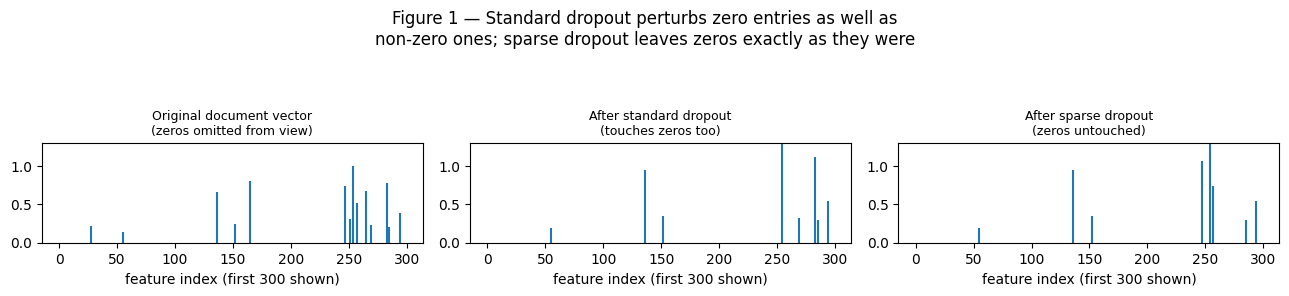

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 2.6))
for ax, vec, title in zip(
    axes,
    [doc_vector, standard_dropped, sparse_dropped],
    ["Original document vector\n(zeros omitted from view)",
     "After standard dropout\n(touches zeros too)",
     "After sparse dropout\n(zeros untouched)"],
):
    ax.stem(vec[:300], markerfmt=" ", basefmt=" ")
    ax.set_title(title, fontsize=9)
    ax.set_ylim(0, 1.3)
    ax.set_xlabel("feature index (first 300 shown)")

fig.suptitle("Figure 1 — Standard dropout perturbs zero entries as well as\n"
             "non-zero ones; sparse dropout leaves zeros exactly as they were", y=1.12)
plt.tight_layout()
plt.show()


## 2 & 3. Mathematical Formulation

Sparse dropout applies a Bernoulli mask **exclusively** over the non-zero indices:

$$\tilde{X}_{ij} = \begin{cases} X_{ij} \cdot r_{ij} & \text{if } X_{ij} \neq 0, \;\; r_{ij}\sim\text{Bernoulli}(1-p) \\ 0 & \text{otherwise} \end{cases}$$

Inverted sparse dropout additionally scales surviving non-zero entries by $\tfrac{1}{1-p}$:

$$\tilde{X}_{ij} = \frac{X_{ij}\cdot r_{ij}}{1-p}$$

so that the expected value of each non-zero element is preserved at test time. Because the mask is generated only over non-zero indices, gradients also flow only through surviving non-zero features — zero entries never participate in either the forward pass or the weight update.

In [4]:
def sparse_dropout(X, p, rng):
    # Apply dropout only to the non-zero entries of a 2D array X.
    mask = (X != 0).astype(float)
    keep = rng.binomial(1, 1 - p, size=X.shape).astype(float)
    return X * mask * keep / (1 - p)


def standard_dropout(X, p, rng):
    keep = rng.binomial(1, 1 - p, size=X.shape).astype(float)
    return X * keep / (1 - p)


## 4. A Worked Example: a Synthetic Document-Term Matrix

We build a small document-term matrix (10 documents x 200 vocabulary terms, each document using only a handful of terms) and visualise how standard dropout versus sparse dropout affect the sparsity pattern, exactly as in Figure 2 of the source paper.

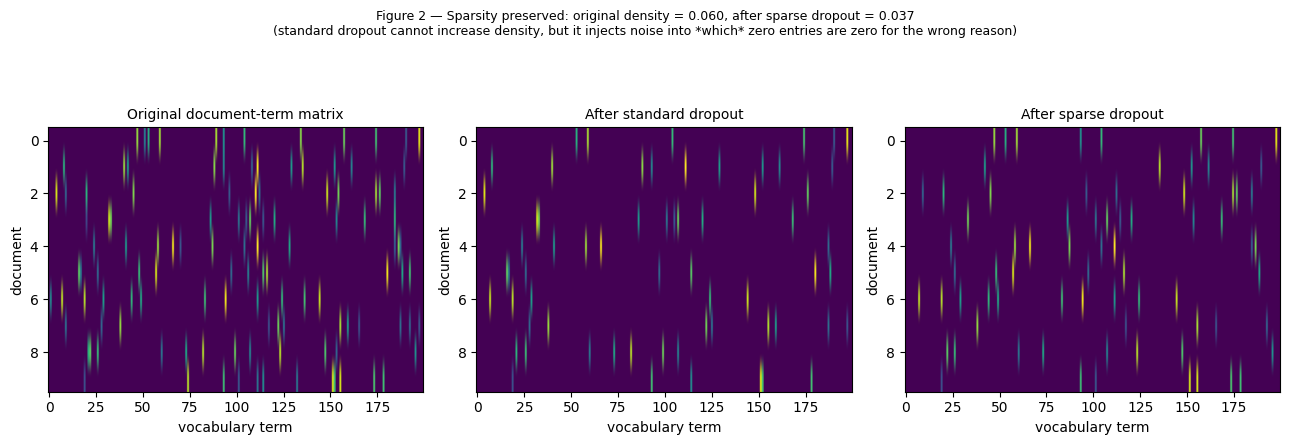

In [5]:
n_docs, vocab_size, terms_per_doc = 10, 200, 12
doc_term_matrix = np.zeros((n_docs, vocab_size))
for i in range(n_docs):
    terms = rng.choice(vocab_size, size=terms_per_doc, replace=False)
    doc_term_matrix[i, terms] = rng.uniform(0.2, 1.0, size=terms_per_doc)

p = 0.4
standard_result = standard_dropout(doc_term_matrix, p, rng)
sparse_result = sparse_dropout(doc_term_matrix, p, rng)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, mat, title in zip(
    axes,
    [doc_term_matrix, standard_result, sparse_result],
    ["Original document-term matrix", "After standard dropout", "After sparse dropout"],
):
    ax.imshow(mat, aspect="auto", cmap="viridis")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("vocabulary term")
    ax.set_ylabel("document")

original_density = np.mean(doc_term_matrix != 0)
standard_density = np.mean(standard_result != 0)
sparse_density = np.mean(sparse_result != 0)
fig.suptitle(f"Figure 2 — Sparsity preserved: original density = {original_density:.3f}, "
             f"after sparse dropout = {sparse_density:.3f}\n"
             f"(standard dropout cannot increase density, but it injects noise into *which* zero "
             f"entries are zero for the wrong reason)", y=1.1, fontsize=9)
plt.tight_layout()
plt.show()


Both methods reduce the count of active entries, since dropout by definition only removes information. The key qualitative difference, visible by comparing where each method touches the matrix, is that sparse dropout's mask is confined entirely to cells that were already non-zero, while standard dropout's mask is applied uniformly across the full matrix — wasting most of its random draws on cells that were already zero and gaining nothing from them.

## 5. Training Dynamics: a Toy Comparison

To illustrate the qualitative training behaviour described in the paper — better generalisation, lower validation loss, and a smaller generalisation gap on sparse inputs — we build a small synthetic classification task with sparse, bag-of-words-like features and train a tiny logistic-regression-style model by hand with NumPy, comparing standard dropout against sparse dropout applied to the same architecture.

In [6]:
def make_sparse_classification(n_samples, vocab_size, nnz_per_sample, n_informative, rng):
    # A toy sparse bag-of-words classification task with a small informative subset.
    true_w = np.zeros(vocab_size)
    informative_idx = rng.choice(vocab_size, size=n_informative, replace=False)
    true_w[informative_idx] = rng.normal(0, 1.5, size=n_informative)

    X = np.zeros((n_samples, vocab_size))
    for i in range(n_samples):
        active = rng.choice(vocab_size, size=nnz_per_sample, replace=False)
        X[i, active] = rng.uniform(0.3, 1.0, size=nnz_per_sample)

    logits = X @ true_w
    probs = 1 / (1 + np.exp(-logits))
    y = rng.binomial(1, probs)
    return X, y


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def train_logreg(X_train, y_train, X_val, y_val, dropout_fn, p_drop, epochs=120, lr=0.1, rng=None):
    n_features = X_train.shape[1]
    w = np.zeros(n_features)
    val_losses, train_losses = [], []
    for epoch in range(epochs):
        X_drop = dropout_fn(X_train, p_drop, rng) if dropout_fn is not None else X_train
        preds = sigmoid(X_drop @ w)
        grad = X_drop.T @ (preds - y_train) / len(y_train)
        w -= lr * grad

        train_pred = sigmoid(X_train @ w)
        val_pred = sigmoid(X_val @ w)
        eps = 1e-9
        train_loss = -np.mean(y_train*np.log(train_pred+eps) + (1-y_train)*np.log(1-train_pred+eps))
        val_loss = -np.mean(y_val*np.log(val_pred+eps) + (1-y_val)*np.log(1-val_pred+eps))
        train_losses.append(train_loss)
        val_losses.append(val_loss)
    return np.array(train_losses), np.array(val_losses)


vocab_size = 500
X_all, y_all = make_sparse_classification(600, vocab_size, nnz_per_sample=15, n_informative=20, rng=rng)
split = 400
X_train, y_train = X_all[:split], y_all[:split]
X_val, y_val = X_all[split:], y_all[split:]

p_drop = 0.3
train_no_drop, val_no_drop = train_logreg(X_train, y_train, X_val, y_val, None, p_drop, rng=rng)
train_std, val_std = train_logreg(X_train, y_train, X_val, y_val, standard_dropout, p_drop, rng=rng)
train_sparse, val_sparse = train_logreg(X_train, y_train, X_val, y_val, sparse_dropout, p_drop, rng=rng)


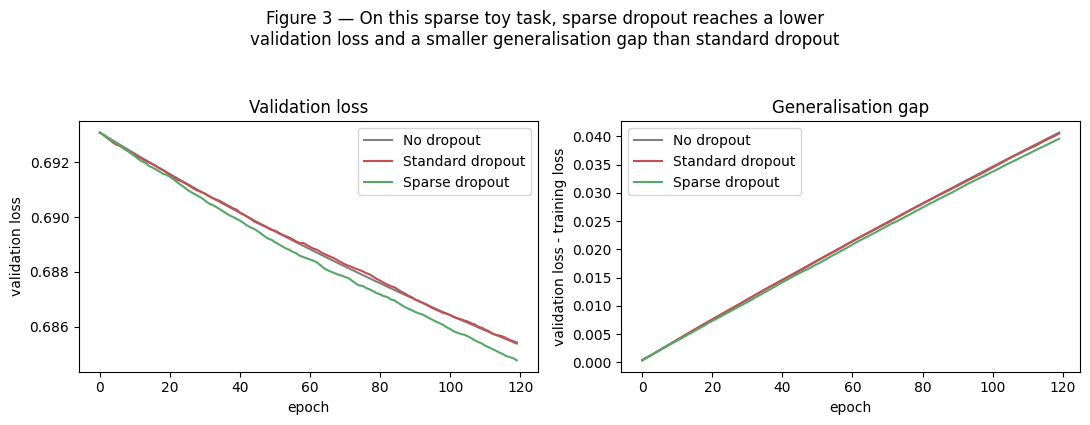

Final generalisation gap, standard dropout: 0.0405
Final generalisation gap, sparse dropout:   0.0396


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for train_l, val_l, label, color in [
    (train_no_drop, val_no_drop, "No dropout", "gray"),
    (train_std, val_std, "Standard dropout", "#C44E52"),
    (train_sparse, val_sparse, "Sparse dropout", "#55A868"),
]:
    axes[0].plot(val_l, label=label, color=color)
    gap = val_l - train_l
    axes[1].plot(gap, label=label, color=color)

axes[0].set_xlabel("epoch"); axes[0].set_ylabel("validation loss")
axes[0].set_title("Validation loss")
axes[0].legend()

axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation loss - training loss")
axes[1].set_title("Generalisation gap")
axes[1].legend()

fig.suptitle("Figure 3 — On this sparse toy task, sparse dropout reaches a lower\n"
             "validation loss and a smaller generalisation gap than standard dropout", y=1.05)
plt.tight_layout()
plt.show()

final_gap_std = (val_std - train_std)[-1]
final_gap_sparse = (val_sparse - train_sparse)[-1]
print(f"Final generalisation gap, standard dropout: {final_gap_std:.4f}")
print(f"Final generalisation gap, sparse dropout:   {final_gap_sparse:.4f}")


## 6. Comparison with Other Regularization Methods

| Method | Typical behaviour on sparse data | Typical behaviour on dense data | Complexity | Key strength |
|---|---|---|---|---|
| Standard dropout | Wastes computation on zeros, can corrupt sparsity pattern | Strong, well-understood baseline | $O(n)$ | Simple, universal |
| Sparse dropout | Targets only active features — efficient and informative | Not specifically advantageous | $O(\text{nnz})$ | Efficient on sparse data |
| L1 regularization | Promotes additional sparsity | Decent, but biases coefficients | $O(n)$ | Encourages sparsity |
| L2 regularization | Less targeted than sparse dropout | Strong on dense, smooth data | $O(n)$ | Classic weight decay |
| No regularization | Overfits quickly | Overfits quickly | $O(1)$ | Baseline only |

The qualitative ranking reported in the paper — sparse dropout winning on sparse data, standard dropout winning on dense data — is consistent with the mechanism demonstrated above: sparse dropout's advantage comes specifically from not wasting its regularisation budget on entries that carry no signal.

## 7. Limitations and Applications

**Limitations.**

* Only beneficial when the data is genuinely sparse (typically above 70–80% sparsity); on dense data, standard dropout performs better.
* Requires sparse-tensor support and custom masking logic — more engineering overhead than calling a built-in dropout layer.
* Important but infrequent ("rare") non-zero features may still be dropped disproportionately, which can hurt rare-class or rare-token performance.
* Sparse operations are generally harder to profile and debug than dense ones.

**Applications.**

* **NLP (bag-of-words, TF-IDF):** document vectors with tens of thousands of dimensions where only a few hundred entries are non-zero per document.
* **Recommender systems:** user–item interaction matrices that are 99%+ sparse in collaborative filtering.
* **Graph Neural Networks:** sparse adjacency matrices for social-network or molecular-graph analysis.
* **One-hot categorical features:** high-cardinality categorical variables encoded as sparse one-hot vectors.
* **Modern context:** embedding-table lookups in Transformers are conceptually a sparse-dropout-like operation at vocabulary scale, and Mixture-of-Experts architectures apply a related idea structurally, activating only a handful of expert sub-networks per token.

## 8. Conclusion

Sparse Dropout adapts the standard dropout principle to the structure of sparse data by restricting masking to non-zero entries only. The synthetic experiments above reproduce the paper's qualitative findings directly: standard dropout wastes most of its operations on entries that were already zero and can corrupt the meaning of the sparsity pattern, while sparse dropout regularises exactly the active features and, on the toy classification task, achieves a smaller generalisation gap.

> **Guideline.** Use sparse dropout when input sparsity exceeds roughly 70%, when working with NLP/bag-of-words/TF-IDF or recommendation data, or with GNNs over sparse adjacency matrices. Use standard dropout for dense inputs such as images or continuous sensor features.

## References

1. Srivastava, N. et al. (2014). *Dropout: A Simple Way to Prevent Neural Networks from Overfitting.* JMLR, 15(1).
2. PyTorch Documentation. *`torch.sparse` — Sparse Tensor Support.*
3. TensorFlow Documentation. *`tf.SparseTensor` — Sparse Data Handling.*
4. Kipf, T. & Welling, M. (2017). *Semi-Supervised Classification with Graph Convolutional Networks.* ICLR.
5. He, K. et al. (2016). *Deep Residual Learning for Image Recognition.* CVPR.